# NFL Play Prediction - Exploratory Data Analysis
This notebook explores NFL play-by-play data to analyze personnel, formation, and game context as predictors of play type.

In [8]:
import nfl_data_py as nfl
import pandas as pd

df = nfl.import_pbp_data([2025])
print(df.shape)
print(df.columns.tolist())

2025 done.
Downcasting floats.
(48771, 396)
['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'pass_length', 'pass_location', 'air_yards', 'yards_after_catch', 'run_location', 'run_gap', 'field_goal_result', 'kick_distance', 'extra_point_result', 'two_point_conv_result', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'timeout_team', 'td_team', 'td_player_name', 'td_player_id', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post

## Data Overview
Examing the shape and columns of the provided dataset.

In [10]:
df_team = df[df['posteam'] == 'KC']
df_week = df[df['week'] == 1]
df_filtered = df[(df['posteam'] == 'KC') & (df['week'] == 1)]

In [11]:
# View columns related to three specified categories
personnel_cols = [col for col in df.columns if 'personnel' in col.lower()]
formation_cols = [col for col in df.columns if 'formation' in col.lower()]
print("Personnel columns:", personnel_cols)
print("Formation columns:", formation_cols)

Personnel columns: ['offense_personnel', 'defense_personnel']
Formation columns: ['offense_formation']


In [12]:
df_clean = df[df['play_type'].isin(['pass', 'run'])].copy()
print(df_clean['play_type'].value_counts())

play_type
pass    19735
run     14893
Name: count, dtype: int64


In [13]:
key_cols = ['play_type', 'offense_formation', 'offense_personnel', 'down', 'ydstogo', 'score_differential', 'quarter_seconds_remaining']
print(df_clean[key_cols].isnull().sum())

play_type                      0
offense_formation             58
offense_personnel              0
down                         125
ydstogo                        0
score_differential             0
quarter_seconds_remaining      0
dtype: int64


In [ ]:
# Remove rows with missing values in key columns
df_clean = df_clean.dropna(subset=key_cols)
print(df_clean.shape)

# Preview key columns
print(df_clean[key_cols].head(10))

# See unique values in formation and personnel
print(df_clean['offense_formation'].value_counts())
print(df_clean['offense_personnel'].value_counts())

In [15]:
# Extract RB, TE, WR counts from personnel string
df_clean['RB'] = df_clean['offense_personnel'].str.extract(r'(\d+) RB').astype(float)
df_clean['TE'] = df_clean['offense_personnel'].str.extract(r'(\d+) TE').astype(float)
df_clean['WR'] = df_clean['offense_personnel'].str.extract(r'(\d+) WR').astype(float)

print(df_clean[['offense_personnel', 'RB', 'TE', 'WR']].head(10))
print(df_clean[['RB', 'TE', 'WR']].value_counts())

                        offense_personnel   RB   TE   WR
2   1 C, 2 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR  1.0  3.0  1.0
3   1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
4   1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
5   1 C, 2 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR  1.0  1.0  3.0
6   1 C, 2 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR  1.0  1.0  3.0
8        2 C, 1 QB, 1 RB, 3 T, 2 TE, 2 WR  1.0  2.0  2.0
9        2 C, 1 QB, 1 RB, 3 T, 1 TE, 3 WR  1.0  1.0  3.0
10       2 C, 1 QB, 1 RB, 3 T, 1 TE, 3 WR  1.0  1.0  3.0
12  1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
13  1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
RB   TE   WR 
1.0  1.0  3.0    19332
     2.0  2.0     7452
     1.0  2.0     2230
     3.0  1.0     1751
     2.0  1.0     1506
2.0  1.0  2.0      636
1.0  1.0  1.0      244
2.0  2.0  1.0      104
     1.0  1.0       29
     3.0  4.0        2
     1.0  3.0        1
Name: count, dtype: int64


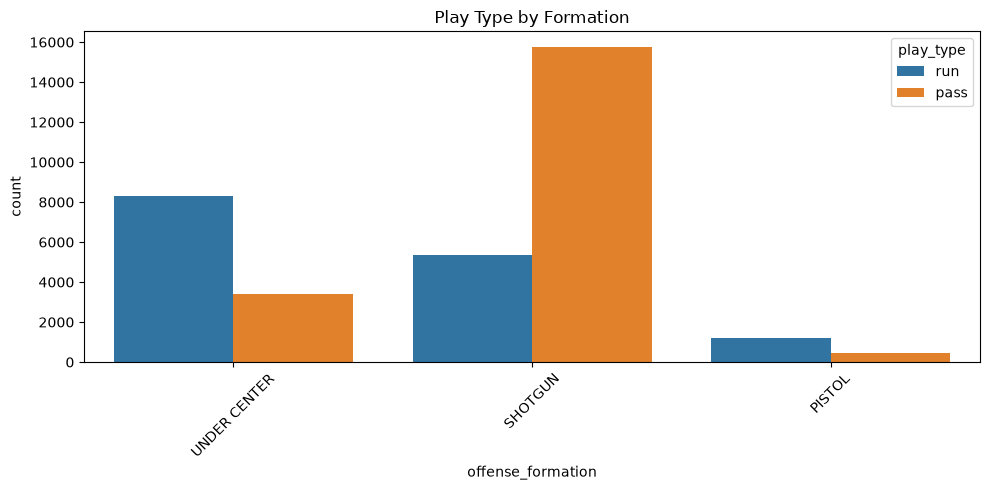

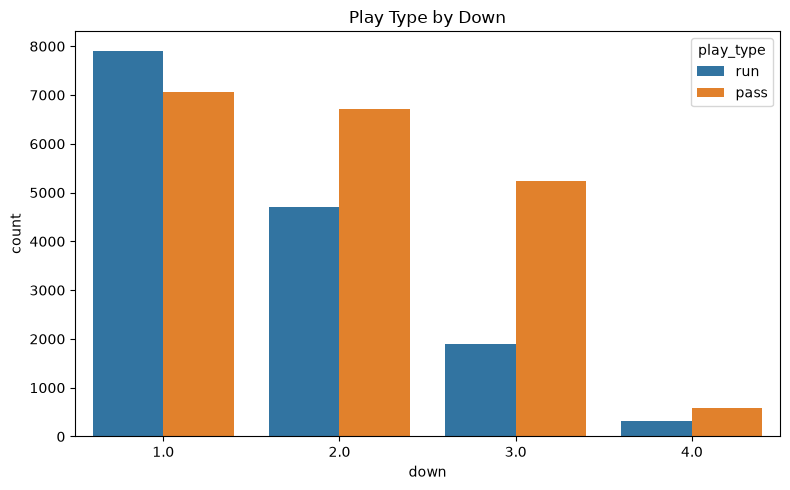

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Play type by formation
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='offense_formation', hue='play_type')
plt.title('Play Type by Formation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Play type by down
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='down', hue='play_type')
plt.title('Play Type by Down')
plt.tight_layout()
plt.show()